# Intro to Neural Shading

<table style="border:none;width:100%"><tr style="border:none"><td style="border:none;vertical-align:top;padding:0 14px 0 0"><div style="font-size:15px;font-weight:700;margin-bottom:6px">What you are going to build</div><div style="font-size:13.5px;line-height:1.5">A material whose appearance is a <b>small neural network plus a texture</b>, trained on rendered images, that a fragment shader can evaluate in place of a BRDF.<br><br>You will train one, find out the hard way why its inputs have to be expressed in the right frame, fix that, and then look at what the result costs to run on real hardware.<br><br><span style='color:#6b7280'>Assumed: you know what a BRDF, a normal and a fragment shader are. Not assumed: any ML.</span></div></td><td style="border:none;width:44%;vertical-align:top"></td></tr></table>

The one idea, before any code: **the network replaces the BRDF call.** Everything else exists
to produce something a shader can evaluate per pixel.

## 1 - Pick a material

Four are available, each a sphere rendered from 200 cameras under 4 lights. These images are
the **ground truth**, not any model's output.

<table style="border:none;width:100%"><tr style="border:none"><td style="border:none;text-align:center;padding:0 6px">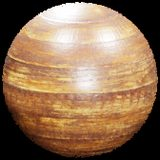<div style="font-size:12.5px;font-weight:700;margin-top:4px">wood_table</div><div style="font-size:11px;color:#6b7280;line-height:1.35">diffuse, fine grain - trains fastest</div></td><td style="border:none;text-align:center;padding:0 6px">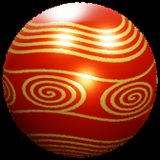<div style="font-size:12.5px;font-weight:700;margin-top:4px">ornament 014</div><div style="font-size:11px;color:#6b7280;line-height:1.35">red + gold spirals, metallic</div></td><td style="border:none;text-align:center;padding:0 6px">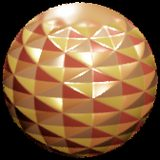<div style="font-size:12.5px;font-weight:700;margin-top:4px">ornament 018</div><div style="font-size:11px;color:#6b7280;line-height:1.35">gold facets, sharp highlights</div></td><td style="border:none;text-align:center;padding:0 6px">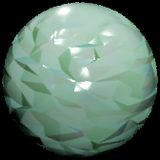<div style="font-size:12.5px;font-weight:700;margin-top:4px">ornament 021</div><div style="font-size:11px;color:#6b7280;line-height:1.35">pale green, glossy relief</div></td></tr></table>

`wood_table` is nearly diffuse and trains fastest. The ornaments are metallic, with sharp
view-dependent highlights - the hard case for a small network.

In [ ]:
# Set up imports and the device, then download the chosen material (~18 MB).
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")   # only matters on a Mac, not Colab

import math, time, json, urllib.request
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

MATERIAL = "wood_table"  #@param ["wood_table", "ChristmasTreeOrnament014", "ChristmasTreeOrnament018", "ChristmasTreeOrnament021"]

# A GPU runtime matters here: the work is dominated by kernel launches rather than
# arithmetic, so a CPU runtime gets ~5-10x fewer training steps in the same wall time.
if torch.cuda.is_available():
    DEV = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEV = torch.device("mps")
else:
    DEV = torch.device("cpu")
    print("!! No GPU. Runtime > Change runtime type > T4 GPU, then rerun this cell.")
print("device:", DEV, "| torch", torch.__version__)

# Get the ~18 MB slice for the chosen material. Sources are tried in order: a file already
# beside the notebook, then whatever hosting was configured, then an interactive upload.
DATA_BASE = "https://github.com/Badhri7/Neural_Shading_Intro/releases/download/v1"
DATA_URLS = {}
DRIVE_IDS = {}

NPZ = f"neural_shading_{MATERIAL}.npz"
url = DATA_URLS.get(MATERIAL) or (f"{DATA_BASE}/{NPZ}" if DATA_BASE else "")
drive_id = DRIVE_IDS.get(MATERIAL, "")

if os.path.exists(NPZ):
    print("using the copy already in this session")
elif url:
    print(f"downloading {MATERIAL} ...")
    urllib.request.urlretrieve(url, NPZ)
elif drive_id and not drive_id.startswith("PASTE_"):
    print(f"downloading {MATERIAL} from Drive ...")
    import gdown                                    # preinstalled on Colab
    gdown.download(id=drive_id, output=NPZ, quiet=False)
else:
    # No public host: the file lives somewhere only you can reach (Box, an internal share),
    # so download it in your browser and hand it to this session.
    print(f"Upload {NPZ} - pick it in the dialog below,")
    print("or drag it into the Files pane on the left and rerun this cell.")
    from google.colab import files
    files.upload()

# A host that needs a login hands back an HTML sign-in page instead of the data, and numpy
# would then fail with a confusing "not a zip file". .npz IS a zip, so byte 0 must be "PK".
with open(NPZ, "rb") as _fh:
    if _fh.read(2) != b"PK":
        os.remove(NPZ)
        raise SystemExit(f"{NPZ} is not a valid .npz - the server probably returned a "
                         f"sign-in page. Download it in your browser and upload it here.")
print("data:", NPZ, f"{os.path.getsize(NPZ)/2**20:.1f} MB")

## 2 - Load the dataset

<table style="border:none;width:100%"><tr style="border:none"><td style="border:none;vertical-align:top;padding:0 14px 0 0"><div style="font-size:15px;font-weight:700;margin-bottom:6px">A BRDF, sampled</div><div style="font-size:13.5px;line-height:1.5">Every <b>pixel of every render</b> is one training row:<ul style='margin:6px 0 0 18px;padding:0'><li><code>uv</code> - where on the material</li><li><code>omega_i</code> - toward the light</li><li><code>omega_o</code> - toward the camera</li><li><code>normal</code> - the surface orientation</li><li><code>rgb</code> - what the renderer computed</li></ul></div></td><td style="border:none;width:40%;vertical-align:top"></td></tr></table>

`omega_i` and `omega_o` are not stored - both are derivable, so the next cell rebuilds them:
`omega_i` from the light index, `omega_o` from `pos = centre + R * normal` and the camera.

In [ ]:
# Load the slice, then rebuild the two direction vectors from the geometry.
d = np.load(NPZ, allow_pickle=False)
meta = json.loads(str(d["meta"]))

LIGHT_ENERGY = meta["light_energy"]                              # same for all 4 lights
RADIUS       = meta["sphere_radius"]
CENTRE       = torch.tensor(meta["sphere_centre_rk"], device=DEV)
LIGHT_DIRS   = torch.tensor(d["light_dirs_rk"], device=DEV)      # (4, 3)
CAMPOS       = torch.tensor(d["campos_rk"], device=DEV)          # (200, 3)

uv      = torch.tensor(d["uv"], device=DEV).float()
normal  = F.normalize(torch.tensor(d["normal"], device=DEV).float(), dim=-1)
rgb     = torch.tensor(d["rgb"], device=DEV).float()
cam_i   = torch.tensor(d["cam_idx"], device=DEV).long()
light_i = torch.tensor(d["light_idx"], device=DEV).long()

omega_i = LIGHT_DIRS[light_i]                                    # this row's light direction
pos     = CENTRE[None] + RADIUS * normal                         # its point on the sphere
omega_o = F.normalize(CAMPOS[cam_i] - pos, dim=-1)               # toward its camera

# What the network predicts. rgb = f(...) * Li * cos(theta_i), so dividing out the light
# intensity leaves the part that depends only on the material and the two directions.
# Never tone-map this: the relation is linear, and a shader feeds linear Li at runtime.
target = rgb / LIGHT_ENERGY

# Hold out every 5th camera. The model is only ever scored on cameras it never saw.
is_test    = (cam_i % 5) == 0
train_rows = torch.nonzero(~is_test, as_tuple=True)[0]
test_rows  = torch.nonzero(is_test,  as_tuple=True)[0]

print(f"{meta['material']}: {len(uv):,} rows sampled from {meta['source_rows']:,}")
print(f"train {len(train_rows):,} | held-out {len(test_rows):,} rows")

## 3 - What the model reads, and what it has to reproduce

Four maps - **colour, roughness, metallic, normal** - are 8 scalar channels. That 8-vector per
texel is the entire material input. Nothing in it says how light scatters; that is what the
network has to learn.

In [ ]:
# Load the four maps and stack them into the 8 channels the model reads.
MAPS = {k: torch.tensor(d[f"map_{k}"], device=DEV).float() / 255.0
        for k in ("color", "roughness", "metallic", "normal")}

PBR = torch.cat([MAPS["color"] ** 2.2,             # sRGB -> linear
                 MAPS["roughness"][..., :1],
                 MAPS["metallic"][..., :1],
                 MAPS["normal"] * 2.0 - 1.0],      # [0,1] -> [-1,1]
                dim=-1).permute(2, 0, 1).unsqueeze(0).contiguous()      # (1, 8, H, W)

CH_NAMES = ["colour R", "colour G", "colour B", "roughness",
            "metallic", "normal x", "normal y", "normal z"]

def show_channels(chw, names, title):
    """Show a (C,H,W) tensor as C grayscale panels, each stretched 1-99 percentile."""
    g = chw.detach().cpu().numpy()
    fig, ax = plt.subplots(1, g.shape[0], figsize=(1.6 * g.shape[0], 2.1))
    for c in range(g.shape[0]):
        lo, hi = np.percentile(g[c], 1), np.percentile(g[c], 99)
        ax[c].imshow(np.clip((g[c] - lo) / max(hi - lo, 1e-6), 0, 1), cmap="gray")
        ax[c].set_title(names[c], fontsize=8.5); ax[c].axis("off")
    fig.suptitle(title, fontsize=11); plt.tight_layout(); plt.show()

show_channels(PBR[0], CH_NAMES, "the 8-D input: what a human wrote down about this material")

In [ ]:
# Sample those 8 channels at arbitrary uv - the same bilinear fetch a shader does.
def sample_pbr(uv_batch):
    g = uv_batch.view(1, -1, 1, 2) * 2.0 - 1.0
    out = F.grid_sample(PBR, g, mode="bilinear", padding_mode="border", align_corners=True)
    return out.squeeze(-1).squeeze(0).transpose(0, 1)                   # (B, 8)

print("sampled shape:", tuple(sample_pbr(uv[:5]).shape))

### And this is the target

Held-out cameras, rendered from the dataset itself. This is what the network has to reproduce
from `uv` and two directions.

In [ ]:
# Display helpers: tone mapping, an image renderer, PSNR, and a comparison grid.

def _aces(x):
    return np.clip((x * (2.51*x + 0.03)) / (x * (2.43*x + 0.59) + 0.14), 0, 1)

def tonemap(hdr):
    """HDR radiance -> displayable sRGB. Display only; training stays linear."""
    x = _aces(hdr)
    return np.clip(np.where(x <= 0.0031308, x*12.92,
                            1.055*np.power(np.clip(x, 1e-9, None), 1/2.4) - 0.055), 0, 1)

@torch.no_grad()
def render(cam, decoder=None, z_of=None, res=112, use_local=True):
    """Image for one camera: ground truth, plus the model's version if one is given.

    Returns (gt, prediction, mask). The 4 lights are accumulated separately and summed,
    which is exact because radiance is linear in the lights.
    """
    fwd = F.normalize(CAMPOS[cam] - CENTRE, dim=-1)
    up_ref = torch.tensor([1., 0., 0.] if abs(float(fwd[1])) > 0.99 else [0., 1., 0.], device=DEV)
    right = F.normalize(torch.cross(up_ref, fwd, dim=-1), dim=-1)
    up = torch.cross(fwd, right, dim=-1)
    gt_img = np.zeros((res, res, 3), np.float32)
    pr_img = np.zeros((res, res, 3), np.float32)
    hit = np.zeros((res, res), bool)

    for k in range(len(LIGHT_DIRS)):
        rows = torch.nonzero((cam_i == cam) & (light_i == k), as_tuple=True)[0]
        if len(rows) == 0:
            continue
        n = normal[rows]
        vis = (n * fwd).sum(-1) > 0.05                        # front-facing samples only
        rows, n = rows[vis], n[vis]
        if len(rows) == 0:
            continue
        # screen position from the geometry (orthographic stand-in for the real camera)
        x = (((n*right).sum(-1)*0.5 + 0.5) * (res-1)).cpu().numpy()
        y = (((n*up).sum(-1)*-0.5 + 0.5) * (res-1)).cpu().numpy()
        vals = [(target[rows] * LIGHT_ENERGY).cpu().numpy()]

        if decoder is not None:
            oi, oo = omega_i[rows], omega_o[rows]
            if use_local:
                oi, oo = to_local(n, oi, oo)
            pred = decoder(z_of(uv[rows]), oi, oo)
            lit = ((normal[rows] * omega_i[rows]).sum(-1) > 0).float()[:, None]   # shader does this
            vals.append((pred * lit * LIGHT_ENERGY).cpu().numpy())
        vals = np.concatenate(vals, axis=1)

        # Bilinear splat. Rounding to the nearest pixel would leave ~25% of pixels empty per
        # light, which reads as salt-and-pepper noise once the lights are summed.
        acc = np.zeros((res, res, vals.shape[1]), np.float32)
        w = np.zeros((res, res), np.float32)
        x0, y0 = np.floor(x).astype(np.int64), np.floor(y).astype(np.int64)
        fx, fy = x - x0, y - y0
        for dx, dy, ww in ((0,0,(1-fx)*(1-fy)), (1,0,fx*(1-fy)), (0,1,(1-fx)*fy), (1,1,fx*fy)):
            xi, yi = np.clip(x0+dx, 0, res-1), np.clip(y0+dy, 0, res-1)
            np.add.at(acc, (yi, xi), vals * ww[:, None]); np.add.at(w, (yi, xi), ww)
        occ = w > 1e-6
        den = np.maximum(w, 1e-6)[..., None]
        gt_img += np.where(occ[..., None], acc[..., :3]/den, 0)
        if decoder is not None:
            pr_img += np.where(occ[..., None], acc[..., 3:]/den, 0)
        hit |= occ
    return gt_img, pr_img, hit

def psnr(pred, gt, mask):
    """Image PSNR in display space, over the object only."""
    mse = float(((tonemap(pred)[mask] - tonemap(gt)[mask]) ** 2).mean())
    return 10 * math.log10(1.0 / max(mse, 1e-12))

def show_gt(cams):
    """Ground truth for a few cameras."""
    fig, ax = plt.subplots(1, len(cams), figsize=(2.3*len(cams), 2.5))
    for a, cam in zip(np.atleast_1d(ax), cams):
        gt, _, m = render(cam)
        a.imshow(tonemap(gt) * m[..., None]); a.set_title(f"cam {cam}", fontsize=9); a.axis("off")
    fig.suptitle("held-out cameras, ground truth", fontsize=11); plt.tight_layout(); plt.show()

show_gt(meta["showcase_cams"])

The dark region on the lowest camera is never reached by any of the 4 lights - no samples exist
there. The odd bright speck is path-tracer noise in the original render.

## 4 - The model

<table style="border:none;width:100%"><tr style="border:none"><td style="border:none;vertical-align:top;padding:0 14px 0 0"><div style="font-size:15px;font-weight:700;margin-bottom:6px">Two small networks</div><div style="font-size:13.5px;line-height:1.5"><b>Encoder</b> - the 8 authored numbers to an 8-D <b>latent</b>, per texel.<br><b>Decoder</b> - <code>(z, omega_i, omega_o) -&gt; RGB</code>. This is the part that stands in for the BRDF, and the only part that has to be fast.<br><br>A layer is <code>y = Wx + b</code>: a matrix multiply and an add, exactly what you do to a position, except the matrix is not square. The stack is <b>20 -&gt; 64 -&gt; 64 -&gt; 64 -&gt; 3</b>.</div></td><td style="border:none;width:40%;vertical-align:top"></td></tr></table>

20 inputs = 8 latent + 12 direction components. After each layer, `max(x, 0)`; the output is
`exp(x - 3)`, so radiance cannot come out negative.

In [ ]:
# The two networks, the loss, and the frame transform they all depend on.
LATENT_DIM = 8
DEC_W, DEC_L, N_FRAMES = 64, 3, 2       # decoder width, hidden layers, learned bases
EPS = 1e-6

def to_local(n, *vecs, eps=1e-6):
    """Express directions in the surface frame (t, b, n). local.z is exactly n . v."""
    up_y = torch.tensor([0., 1., 0.], device=n.device).expand_as(n)
    up_x = torch.tensor([1., 0., 0.], device=n.device).expand_as(n)
    up = torch.where(n[:, 1:2].abs() > 0.99, up_x, up_y)       # avoid n parallel to up
    t = F.normalize(torch.cross(up, n, dim=-1), dim=-1, eps=eps)
    b = torch.cross(n, t, dim=-1)
    return [torch.stack([(t*v).sum(-1), (b*v).sum(-1), (n*v).sum(-1)], -1) for v in vecs]

class Encoder(nn.Module):
    """The 8 PBR channels -> an 8-D latent."""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(8, hidden), nn.ReLU(True),
                                 nn.Linear(hidden, hidden), nn.ReLU(True),
                                 nn.Linear(hidden, LATENT_DIM))
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    """(z, omega_i, omega_o) -> rgb / Li. The BRDF replacement.

    nonlinear=False drops every ReLU, which section 8 uses to show what they are for.
    """
    def __init__(self, width=DEC_W, layers=DEC_L, n_frames=N_FRAMES, nonlinear=True):
        super().__init__()
        self.n_frames, self.nonlinear = n_frames, nonlinear
        self.frames = nn.Linear(LATENT_DIM, 6 * n_frames, bias=False)
        net = [nn.Linear(LATENT_DIM + 6 * n_frames, width)]
        if nonlinear: net.append(nn.ReLU(True))
        for _ in range(layers - 1):
            net.append(nn.Linear(width, width))
            if nonlinear: net.append(nn.ReLU(True))
        net.append(nn.Linear(width, 3))
        self.net = nn.Sequential(*net)

    def dirs_to_input(self, z, oi, oo):
        """(z, two directions) -> the flat input vector the matmuls actually see."""
        raw = self.frames(z).view(-1, self.n_frames, 2, 3)     # n_frames (normal, tangent) pairs
        n = F.normalize(raw[:, :, 0], dim=-1, eps=EPS)
        t = raw[:, :, 1]
        t = F.normalize(t - (t * n).sum(-1, keepdim=True) * n, dim=-1, eps=EPS)
        basis = torch.stack([t, torch.cross(n, t, dim=-1), n], dim=-2)     # rows are t, b, n
        li = torch.einsum("bnij,bj->bni", basis, oi).flatten(1)
        lo = torch.einsum("bnij,bj->bni", basis, oo).flatten(1)
        return torch.cat([z, li, lo], -1)                      # (B, 20)

    def forward(self, z, oi, oo):
        return torch.exp(self.net(self.dirs_to_input(z, oi, oo)) - 3.0)

print("decoder parameters (3x64):", sum(p.numel() for p in Decoder().parameters()))

## 5 - Choose how to measure "wrong"

One number to minimise. It is the only place you say what "wrong" means.

| | |
|---|---|
| **log-L1** | `mean( |log(pred) − log(target)| )` |
| **plain L1** | `mean( |pred − target| )` |
| **MSE on linear** | `mean( (pred − target)² )` |

The cell prints what each charges for the **same 10% error** at four brightnesses.

In [ ]:
# The three candidate losses, and what each one charges for the same relative error.
def log_l1(pred, tgt):
    """L1 in log space - equal weight to relative error at any brightness."""
    return (torch.log(pred + EPS) - torch.log(tgt + EPS)).abs().mean()

def l1_linear(pred, tgt):
    """Plain L1 on linear radiance."""
    return (pred - tgt).abs().mean()

def mse_linear(pred, tgt):
    """Squared error on linear radiance - the usual default."""
    return ((pred - tgt) ** 2).mean()

LOSSES = {"log-L1": log_l1, "plain L1": l1_linear, "MSE on linear": mse_linear}

LOSS_NAME = "log-L1"  #@param ["log-L1", "plain L1", "MSE on linear"]
loss_fn = LOSSES[LOSS_NAME]

print(f"selected: {LOSS_NAME}\n")
print("cost of a 10% error, at four brightnesses (radiance spans this much in one image):")
print(f"{'target':>10} " + "".join(f"{k:>16}" for k in LOSSES))
for t in (0.01, 0.1, 1.0, 10.0):
    tt = torch.tensor([[t, t, t]], device=DEV)
    pp = tt * 1.1                                        # a 10% overshoot
    row = "".join(f"{float(fn(pp, tt)):>16.6f}" for fn in LOSSES.values())
    print(f"{t:>10.2f} " + row)
print("\nlog-L1 charges the same everywhere; the other two charge almost nothing for being")
print("10% wrong on a dim pixel, so that is what they will do.")

## 6 - Choose the size of the decoder

The decoder runs **per pixel, per light**, so its size is the deployment budget.

- low end `1x16` - 483 parameters
- high end `3x64` - 9,955 parameters, ~20 KB, what this project ships

In [ ]:
# Pick a decoder shape. The table shows what each choice costs.
SHAPE = "3x64"  #@param ["1x16", "1x32", "2x16", "2x32", "2x64", "3x32", "3x64"]

IN_DIM = LATENT_DIM + 6 * N_FRAMES                       # 20
MEASURED_MS = {"2x32": 1.65, "3x32": 1.98, "3x64": 5.88}  # base M5, tuned accelerators

def cost(layers, width):
    """(parameters, multiply-accumulates per shading point) for one decoder shape."""
    par = LATENT_DIM * 6 * N_FRAMES                       # the frames matrix
    par += IN_DIM * width + width                         # first layer
    par += (layers - 1) * (width * width + width)         # hidden layers
    par += width * 3 + 3                                  # output layer
    macs = IN_DIM * width + (layers - 1) * width * width + width * 3
    return par, macs

DEC_L, DEC_W = (int(SHAPE.split("x")[0]), int(SHAPE.split("x")[1]))
ref_par, ref_macs = cost(3, 64)

print(f"selected: {SHAPE}\n")
print(f"{'shape':>7} {'params':>8} {'MACs/point':>11} {'vs 3x64':>8} {'measured on M5':>16}")
for s in ["1x16", "1x32", "2x16", "2x32", "2x64", "3x32", "3x64"]:
    l, w = int(s.split("x")[0]), int(s.split("x")[1])
    par, macs = cost(l, w)
    ms = MEASURED_MS.get(s)
    mark = "  <-- yours" if s == SHAPE else ""
    print(f"{s:>7} {par:>8,} {macs:>11,} {macs/ref_macs:>7.2f}x "
          f"{(f'{ms:.2f} ms' if ms else '-'):>16}{mark}")

## 7 - Keep the non-linearity, or drop it

<table style="border:none;width:100%"><tr style="border:none"><td style="border:none;vertical-align:top;padding:0 14px 0 0"><div style="font-size:15px;font-weight:700;margin-bottom:6px">Why the clamp is not optional</div><div style="font-size:13.5px;line-height:1.5">You already know that <code>M_proj . M_view . M_model</code> collapses into a single matrix - that is why you bake it.<br><br>The same algebra applies to a stack of layers: four matrices <b>are</b> one matrix. So a linear network has exactly the power of a single 20-&gt;3 matrix, no matter how deep you make it. Depth buys nothing without something non-linear between the layers.</div></td><td style="border:none;width:38%;vertical-align:top"></td></tr></table>

`max(x, 0)` stops the collapse. What you get instead is a piecewise-linear function - line
segments, with the joints fitted too.

In [ ]:
# Prove the collapse for the chosen shape, then choose whether to train with clamps.
NONLINEAR = True  #@param {type:"boolean"}

with torch.no_grad():
    probe = Decoder(width=DEC_W, layers=DEC_L, nonlinear=False).to(DEV)
    lins = [m for m in probe.net if isinstance(m, nn.Linear)]
    A, c = lins[0].weight.clone(), lins[0].bias.clone()
    for m in lins[1:]:                                   # fold the stack into one affine map
        A, c = m.weight @ A, m.weight @ c + m.bias

    x = torch.randn(1024, IN_DIM, device=DEV)
    err = (probe.net(x) - (x @ A.T + c)).abs().max().item()

print(f"a linear {SHAPE} stack: {len(lins)} matrices, "
      f"{sum(p.numel() for p in probe.net.parameters()):,} parameters")
print(f"  folds into a single {tuple(A.shape)} matrix + bias = {A.numel()+c.numel()} numbers")
print(f"  max difference between the stack and that one matrix: {err:.2e}")
print(f"\nselected: {'WITH' if NONLINEAR else 'WITHOUT'} the clamps"
      + ("" if NONLINEAR else "  <- you are about to train the collapsed model above"))

## 8 - Train it

Fixed **time** budget, not a fixed step count - so a smaller decoder gets more steps.

**Re-run this cell after changing anything above.** Results accumulate in a table.

In [ ]:
# Build the chosen model and train it. Results accumulate across re-runs.
BATCH = 4096
BUDGET_SECONDS = 20        # every run gets this long

def batch(pool, n=BATCH):
    """A random batch of rows drawn from `pool`."""
    i = pool[torch.randint(0, len(pool), (n,), device=pool.device)]
    return uv[i], omega_i[i], omega_o[i], normal[i], target[i]

def train(decoder, z_of, params, seconds=None, steps=None, loss_fn=None, tag=""):
    """Train for a time budget (predictable runtime) or a step count (fair comparison)."""
    loss_fn = loss_fn or log_l1
    opt = torch.optim.Adam(params, lr=1e-3, betas=(0.9, 0.999), eps=1e-7)
    hist, t0, step = [], time.time(), 0
    while (step < steps) if steps else (time.time() - t0 < seconds):
        b_uv, b_oi, b_oo, b_n, b_tgt = batch(train_rows)
        b_oi, b_oo = to_local(b_n, b_oi, b_oo)           # always in the surface frame
        loss = loss_fn(decoder(z_of(b_uv), b_oi, b_oo), b_tgt)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        if step % 100 == 0:
            hist.append((step, loss.item()))
        step += 1
    print(f"[{tag}] {step:,} steps in {time.time()-t0:.0f}s, final loss {hist[-1][1]:.4f}")
    return step, hist

@torch.no_grad()
def held_out_loss(decoder, z_of, n=200_000):
    """log-L1 on cameras never trained on - comparable across all three loss choices."""
    b_uv, b_oi, b_oo, b_n, b_tgt = batch(test_rows, n)
    b_oi, b_oo = to_local(b_n, b_oi, b_oo)
    return log_l1(decoder(z_of(b_uv), b_oi, b_oo), b_tgt).item()

def show(decoder, z_of, title, cams=None):
    """Ground truth | model | amplified difference, for a few held-out cameras."""
    cams = cams or meta["showcase_cams"]
    fig, ax = plt.subplots(len(cams), 3, figsize=(7, 2.4*len(cams)))
    ax = np.atleast_2d(ax); scores = []
    for r, cam in enumerate(cams):
        gt, pr, m = render(cam, decoder, z_of)
        scores.append(psnr(pr, gt, m))
        ax[r,0].imshow(tonemap(gt)*m[...,None]); ax[r,1].imshow(tonemap(pr)*m[...,None])
        ax[r,2].imshow(np.clip(np.abs(tonemap(pr)-tonemap(gt))*4*m[...,None], 0, 1))
        ax[r,0].set_ylabel(f"cam {cam}\n{scores[-1]:.1f} dB", fontsize=9)
        for c, t in enumerate(("ground truth", "model", "diff x4")):
            ax[r,c].set_xticks([]); ax[r,c].set_yticks([])
            if r == 0: ax[r,c].set_title(t, fontsize=10)
    fig.suptitle(f"{title} - mean {np.mean(scores):.2f} dB"); plt.tight_layout(); plt.show()
    return float(np.mean(scores))

torch.manual_seed(0)
enc = Encoder().to(DEV)
dec = Decoder(width=DEC_W, layers=DEC_L, nonlinear=NONLINEAR).to(DEV)
z_enc = lambda u: enc(sample_pbr(u))
tag = f"{SHAPE}, {LOSS_NAME}{'' if NONLINEAR else ', no clamps'}"

STEPS, hist = train(dec, z_enc, list(enc.parameters()) + list(dec.parameters()),
                    seconds=BUDGET_SECONDS, loss_fn=loss_fn, tag=tag)
PSNR = show(dec, z_enc, tag)

try: RESULTS
except NameError: RESULTS = []               # survives re-runs of this cell
RESULTS.append(dict(shape=SHAPE, loss=LOSS_NAME, clamps=NONLINEAR,
                    steps=STEPS, psnr=PSNR, held=held_out_loss(dec, z_enc)))

print(f"\n{'shape':>6} {'loss':>15} {'clamps':>7} {'steps':>7} {'PSNR':>7} {'held-out':>9}")
for r in RESULTS:
    print(f"{r['shape']:>6} {r['loss']:>15} {str(r['clamps']):>7} {r['steps']:>7,} "
          f"{r['psnr']:>7.2f} {r['held']:>9.4f}")

`held-out` is always log-L1, whatever you trained with, so the three losses stay comparable.

Worth trying:

- Train `3x64` with **MSE on linear** and look at the image, not the number.
- Train `3x64` **without clamps**. The base colour survives; the highlights do not.
- Train `1x16` with log-L1. Then ask whether the extra 9,472 parameters of `3x64` were worth it.
- Train `2x32` and `3x64` back to back. The smaller one gets more steps in the same 20 seconds —
  does it close the gap?

In [ ]:
# The loss curve for the latest run, and whether it generalises to unseen cameras.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.1), gridspec_kw={"width_ratios": [1.7, 1]})
a1.plot(*zip(*hist), lw=1.2, color="#2563eb")
a1.set_yscale("log"); a1.set_xlabel("training step"); a1.set_ylabel(f"{LOSS_NAME} loss")
a1.set_title("what the optimiser saw", fontsize=10); a1.grid(alpha=.3, which="both")

tr, te = hist[-1][1], RESULTS[-1]["held"]
a2.bar([0, 1], [tr, te], 0.5, color=["#9ca3af", "#374151"])
a2.set_xticks([0, 1]); a2.set_xticklabels(["train\n(your loss)", "held-out\n(log-L1)"], fontsize=9)
a2.set_ylabel("loss"); a2.set_title("does it generalise?", fontsize=10)
plt.tight_layout(); plt.show()

### Backprop, deflated

Nudge **one** weight by hand and check the measured change in loss against what autograd said.

In [ ]:
# Finite-difference one weight and compare against the gradient autograd computed.
fixed = batch(train_rows, 8192)          # the SAME batch throughout, or noise swamps the signal

def loss_on(fb):
    b_uv, b_oi, b_oo, b_n, b_tgt = fb
    oi_l, oo_l = to_local(b_n, b_oi, b_oo)
    return loss_fn(dec(z_enc(b_uv), oi_l, oo_l), b_tgt)

W = dec.net[0].weight                     # first decoder layer
i, j = 3, 7

dec.zero_grad(); enc.zero_grad()
loss_on(fixed).backward()
g_auto = W.grad[i, j].item()              # what backprop says

eps = 1e-3                                # what poking it says
with torch.no_grad():
    W[i, j] += eps; l_plus = loss_on(fixed).item()
    W[i, j] -= 2*eps; l_minus = loss_on(fixed).item()
    W[i, j] += eps                        # put it back
g_fd = (l_plus - l_minus) / (2*eps)

print(f"weight W[{i},{j}] = {W[i,j].item():+.5f}")
print(f"  loss at w+eps : {l_plus:.6f}")
print(f"  loss at w-eps : {l_minus:.6f}")
print(f"  slope between : {g_fd:+.5f}   <- measured by nudging")
print(f"  autograd says : {g_auto:+.5f}   <- one backward pass, for every weight at once")
print(f"  ratio         : {g_fd/g_auto:.3f}")
print(f"\nthe update is one line:  w -= lr * grad  ->  "
      f"{W[i,j].item():+.5f} - 1e-3*({g_auto:+.5f}) = {W[i,j].item() - 1e-3*g_auto:+.5f}")

In [ ]:
# What the encoder ended up storing: the 8-D latent, over the whole uv square.
@torch.no_grad()
def latent_image(encoder, res=256):
    t = (torch.arange(res, device=DEV) + 0.5) / res
    gv, gu = torch.meshgrid(t, t, indexing="ij")
    grid_uv = torch.stack([gu, gv], -1).reshape(-1, 2)
    z = torch.cat([encoder(sample_pbr(grid_uv[k:k+65536]))
                   for k in range(0, len(grid_uv), 65536)])
    return z.T.reshape(LATENT_DIM, res, res)

show_channels(latent_image(enc), [f"z{c}" for c in range(LATENT_DIM)],
              "the 8-D latent: what the network chose to keep")

Compare with the 8-D input in section 3. Every channel carries much the same structure at
different polarity - the encoder spent its 8 numbers re-encoding *which region a texel is in*.

This is what ships: bake it to a texture, keep the decoder's weights, throw the encoder away.

## 9 - What you actually ship: arrays and two for loops

Training is over. What is a trained model, concretely?

In [ ]:
# Every tensor in the trained decoder, with its shape.
print(f"{'tensor':<16} {'shape':<14} {'count':>7}")
total = 0
for k, v in dec.state_dict().items():
    print(f"{k:<16} {str(tuple(v.shape)):<14} {v.numel():>7,}")
    total += v.numel()
print(f"{'TOTAL':<16} {'':<14} {total:>7,}  = {total*2/1024:.1f} KB as fp16")

In [ ]:
# The same forward pass in numpy, from those arrays alone - no torch, no modules, no classes.
P = {k: v.detach().cpu().numpy() for k, v in dec.state_dict().items()}

# Find the Linear layers rather than assuming where they are: the indices depend on the shape
# you chose in section 6, and on whether section 7's clamps are in between them.
lin_idx = [i for i, m in enumerate(dec.net) if isinstance(m, nn.Linear)]
Wg = [P[f"net.{i}.weight"] for i in lin_idx]
Bg = [P[f"net.{i}.bias"] for i in lin_idx]
print(f"{len(Wg)} weight matrices at net indices {lin_idx}, clamps={'on' if NONLINEAR else 'off'}")

def numpy_decoder(z, oi, oo):
    """(z, omega_i, omega_o) -> rgb/Li, using only the arrays above."""
    raw = (z @ P["frames.weight"].T).reshape(-1, N_FRAMES, 2, 3)   # learned bases
    n = raw[:, :, 0]; n = n / np.linalg.norm(n, axis=-1, keepdims=True)
    t = raw[:, :, 1]; t = t - (t*n).sum(-1, keepdims=True)*n
    t = t / np.linalg.norm(t, axis=-1, keepdims=True)
    b = np.cross(n, t)
    dot = lambda basis, v: (basis * v[:, None]).sum(-1)
    li = np.stack([dot(t, oi), dot(b, oi), dot(n, oi)], -1).reshape(len(z), -1)
    lo = np.stack([dot(t, oo), dot(b, oo), dot(n, oo)], -1).reshape(len(z), -1)

    h = np.concatenate([z, li, lo], -1)                            # the 20 inputs
    for W_, b_ in zip(Wg[:-1], Bg[:-1]):
        h = h @ W_.T + b_                                          # matmul, add
        if NONLINEAR:
            h = np.maximum(h, 0.0)                                 # the clamp
    return np.exp(h @ Wg[-1].T + Bg[-1] - 3.0)                     # matmul, add, exp

# Same inputs through both implementations.
with torch.no_grad():
    b_uv, b_oi, b_oo, b_n, _ = batch(test_rows, 4096)
    oi_l, oo_l = to_local(b_n, b_oi, b_oo)
    z_b = z_enc(b_uv)
    torch_out = dec(z_b, oi_l, oo_l).cpu().numpy()
np_out = numpy_decoder(z_b.cpu().numpy(), oi_l.cpu().numpy(), oo_l.cpu().numpy())

print("torch :", np.array2string(torch_out[0], precision=5))
print("numpy :", np.array2string(np_out[0], precision=5))
print(f"max abs difference over {len(np_out):,} samples: {np.abs(torch_out-np_out).max():.2e}")
n_mm = len(Wg)
print(f"\n{n_mm} matmuls, each with an add, "
      + (f"{n_mm-1} clamps between them" if NONLINEAR else "no clamps") + ", then exp")

### The same nine operations, in the shader that ships

From `NeuralShader.metal`. The weights arrive as plain buffers and the latent as a texture:

```metal
fragment float4 neural_fragment(V2F in [[stage_in]],
    constant NeuralUniforms& U   [[buffer(0)]],
    constant half* frame_lin     [[buffer(1)]],   // 12x8, the learned bases
    constant half* d0w [[buffer(2)]], constant half* d0b [[buffer(3)]],
    constant half* d1w [[buffer(4)]], constant half* d1b [[buffer(5)]],
    constant half* d2w [[buffer(6)]], constant half* d2b [[buffer(7)]],
    constant half* d3w [[buffer(8)]], constant half* d3b [[buffer(9)]],
    texture2d<half> latA [[texture(0)]],
    texture2d<half> latB [[texture(1)]])
```

The latent is an ordinary texture fetch — this is the line where "appearance lives in a texture"
stops being a metaphor:

```metal
half4 za = latA.sample(smp, uv);  half4 zb = latB.sample(smp, uv);
half z[8] = { za.x,za.y,za.z,za.w, zb.x,zb.y,zb.z,zb.w };
```

**One layer is two nested loops** — the outer over output neurons, the inner dotting one row of
the matrix with the input, then the clamp:

```metal
for (uint o = 0; o < 64; ++o) {              // one output neuron per iteration
    half acc = d1b[o];                       // its bias
    constant half* row = d1w + o*64;         // its row of the weight matrix
    for (uint i = 0; i < 64; i += 4)         // dot that row with the input
        acc += dot(half4(h0[i],h0[i+1],h0[i+2],h0[i+3]),
                   half4(row[i],row[i+1],row[i+2],row[i+3]));
    h1[o] = max(acc, (half)0);               // the clamp from section 8
}
```

That block appears four times with different sizes and that is the entire model. No framework, no
allocation. The `i += 4` with `dot(half4, half4)` is just manual vectorisation.

**And this is where it replaces the BRDF.** The light loop is unchanged from a conventional
shader — same cosine test, same accumulate, same tonemap. One call is different:

```metal
for (uint L = 0; L < nl; ++L) {
    float3 oi = U.lightDirs[L].xyz;
    float noi = dot(nrk, oi);
    if (noi <= 0.0) continue;                // never ask about back-facing lights

    // conventional:
    //   half3 fr = brdf_ggx(nrk, oi, wo, albedo, roughness, metallic);
    // neural: the same question, answered by four matmuls
    half3 fr = exp(half3(ov[0],ov[1],ov[2]) - half(U.expShift));

    rad += float3(fr * scale) * cosv;
}
```

`brdf_ggx` and the MLP answer the same question — given this surface and these two directions,
what fraction of the light reaches the eye. One computes it from a formula somebody derived; the
other reads it out of fitted numbers.

Two details in that shader are graphics thinking rather than ML thinking, and both matter:

- `if (noi <= 0.0) continue;` — the model was never trained on back-facing lights, and skipping
  them is free.
- The first layer's latent-and-view contribution is computed **once before** the light loop, since
  only the light's six inputs change inside it. Loop-invariant hoisting that happens to live
  inside a neural network.

## 10 - What it costs to run

<table style="border:none;width:100%"><tr style="border:none"><td style="border:none;vertical-align:top;padding:0 14px 0 0"><div style="font-size:15px;font-weight:700;margin-bottom:6px">From per-pixel MLP to matrix hardware</div><div style="font-size:13.5px;line-height:1.5">Those matmuls are small, and the M5's <b>Neural Accelerators</b> are matrix units reachable from Metal via cooperative tensors. A per-pixel MLP is a stack of small matmuls, so the decoder can be expressed as tiled matrix work instead of scalar arithmetic.</div></td><td style="border:none;width:38%;vertical-align:top"></td></tr></table>

**How it was used.** The decoder becomes a compute kernel: each threadgroup handles a tile of
**M** shading points, each layer is one `matmul2d`, and bias and ReLU are fused on as an
epilogue. Two launch-geometry numbers dominate everything else:

- **M** — points per threadgroup. Larger M amortises the fixed per-matmul cost: descriptor
  setup, tile ramp-up, and the epilogue's barriers.
- **nsg** — simdgroups per threadgroup, the execution width. The cooperative path wants **few**,
  because its working set is registers plus threadgroup memory. The narrow decoders want `nsg=1`.

Both sat at their defaults (M=16, nsg=4), and neither fix helps alone.

### Measured on a base M5

Model-only GPU time, 4,194,304 shading points, dense, no early exit. "scalar" is ordinary
per-thread arithmetic; "simdgroup" is the ALU matrix path that was previously fastest for narrow
decoders:

| decoder | scalar | simdgroup | accelerators, defaults | **accelerators, tuned** | M | nsg | vs default |
|---|---:|---:|---:|---:|---:|---:|---:|
| 2x32 | 6.59 | 5.48 | 6.71 | **1.65 ms** | 64 | 1 | 4.1x |
| 3x32 | 10.89 | 7.83 | 9.61 | **1.98 ms** | 32 | 1 | 4.9x |
| **3x64** (what you trained) | 37.12 | 23.65 | 16.39 | **5.88 ms** | 32 | 2 | 2.8x |

- **At the defaults the accelerators were slower than the ALU path on 2x32** (6.71 vs 5.48).
  That row is why "small MLPs don't suit matrix units" looked true for a while — a launch-geometry
  artefact, not a property of the hardware.
- **Occupancy was the whole story**, and the narrow decoders wanted the extreme setting.
- Section 6 let you choose the width; this table is what each choice costs in time; this table is what it buys in time. The 3x64 you
  trained costs 3.6x a 2x32 here.

### The caveat that decides whether any of it ships

Cooperative tensors are a **compute-shader** feature. A Vision Pro renderer runs the MLP in a
**fragment** shader, where there is no threadgroup memory and no control over threadgroup size, so
M and nsg have no equivalent. Using the accelerators on device means moving the decoder into a
**compute pass**: G-buffer the interpolated uv / normal / position, dispatch, composite. That is
deferred shading — an architecture decision rather than a tuning one.

## What to take away

1. **A layer is a transform.** `y = Wx + b` is a matrix multiply and an add; a network is a stack
   of them, and the stack is only more than one matrix because of the clamp.
2. **The clamp is what makes depth mean anything.** Section 7 folded a linear stack into a single
   20x3 matrix, to 1e-8. Without it the highlights disappear and the base colour survives.
3. **The loss is a statement about which errors you accept.** Section 5's table shows the three
   candidates charging wildly different amounts for the same 10% mistake, and the model takes you
   at your word.
4. **Backprop is the derivative you would get by poking a weight** - computed for every weight at
   once instead of one at a time.
5. **Capacity is a budget, not a virtue.** The decoder runs per pixel per light; section 6's table
   is the exchange rate between parameters and milliseconds.
6. **A trained model is a data structure**: 9,955 numbers, nine operations, two nested for loops in
   the shader.
7. **Measure cost, do not derive it.** Two launch-geometry constants moved every runtime number in
   section 10 by 3-5x, and none of that is visible in a parameter count.

Things to try:

- Rerun section 8 with each of the three losses, and look at the images rather than the numbers.
- `1x16` versus `3x64`, and decide whether the extra 9,472 parameters earned their place.
- Turn the clamps off and watch the highlights go.
- Swap the material in section 1: the metallic ornaments punish a small decoder far harder than the
  wood does.
- `N_FRAMES = 1` in section 4, to check whether the learned bases were earning their keep.